01. Environment Check
Python  : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
OS      : Windows 10
PyTorch : 2.6.0+cu124
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Ti
02. Package installation complete.
03. All libraries imported successfully.
04. Configuration set.
05. Best model loaded: xcep_rgb_fft_phy
06. Sampled 48 images for visualization (Real: 24 | Fake: 24)
07. Grad-CAM initialized on RGB stream last conv layer.

EXP-08. Grad-CAM Visualization


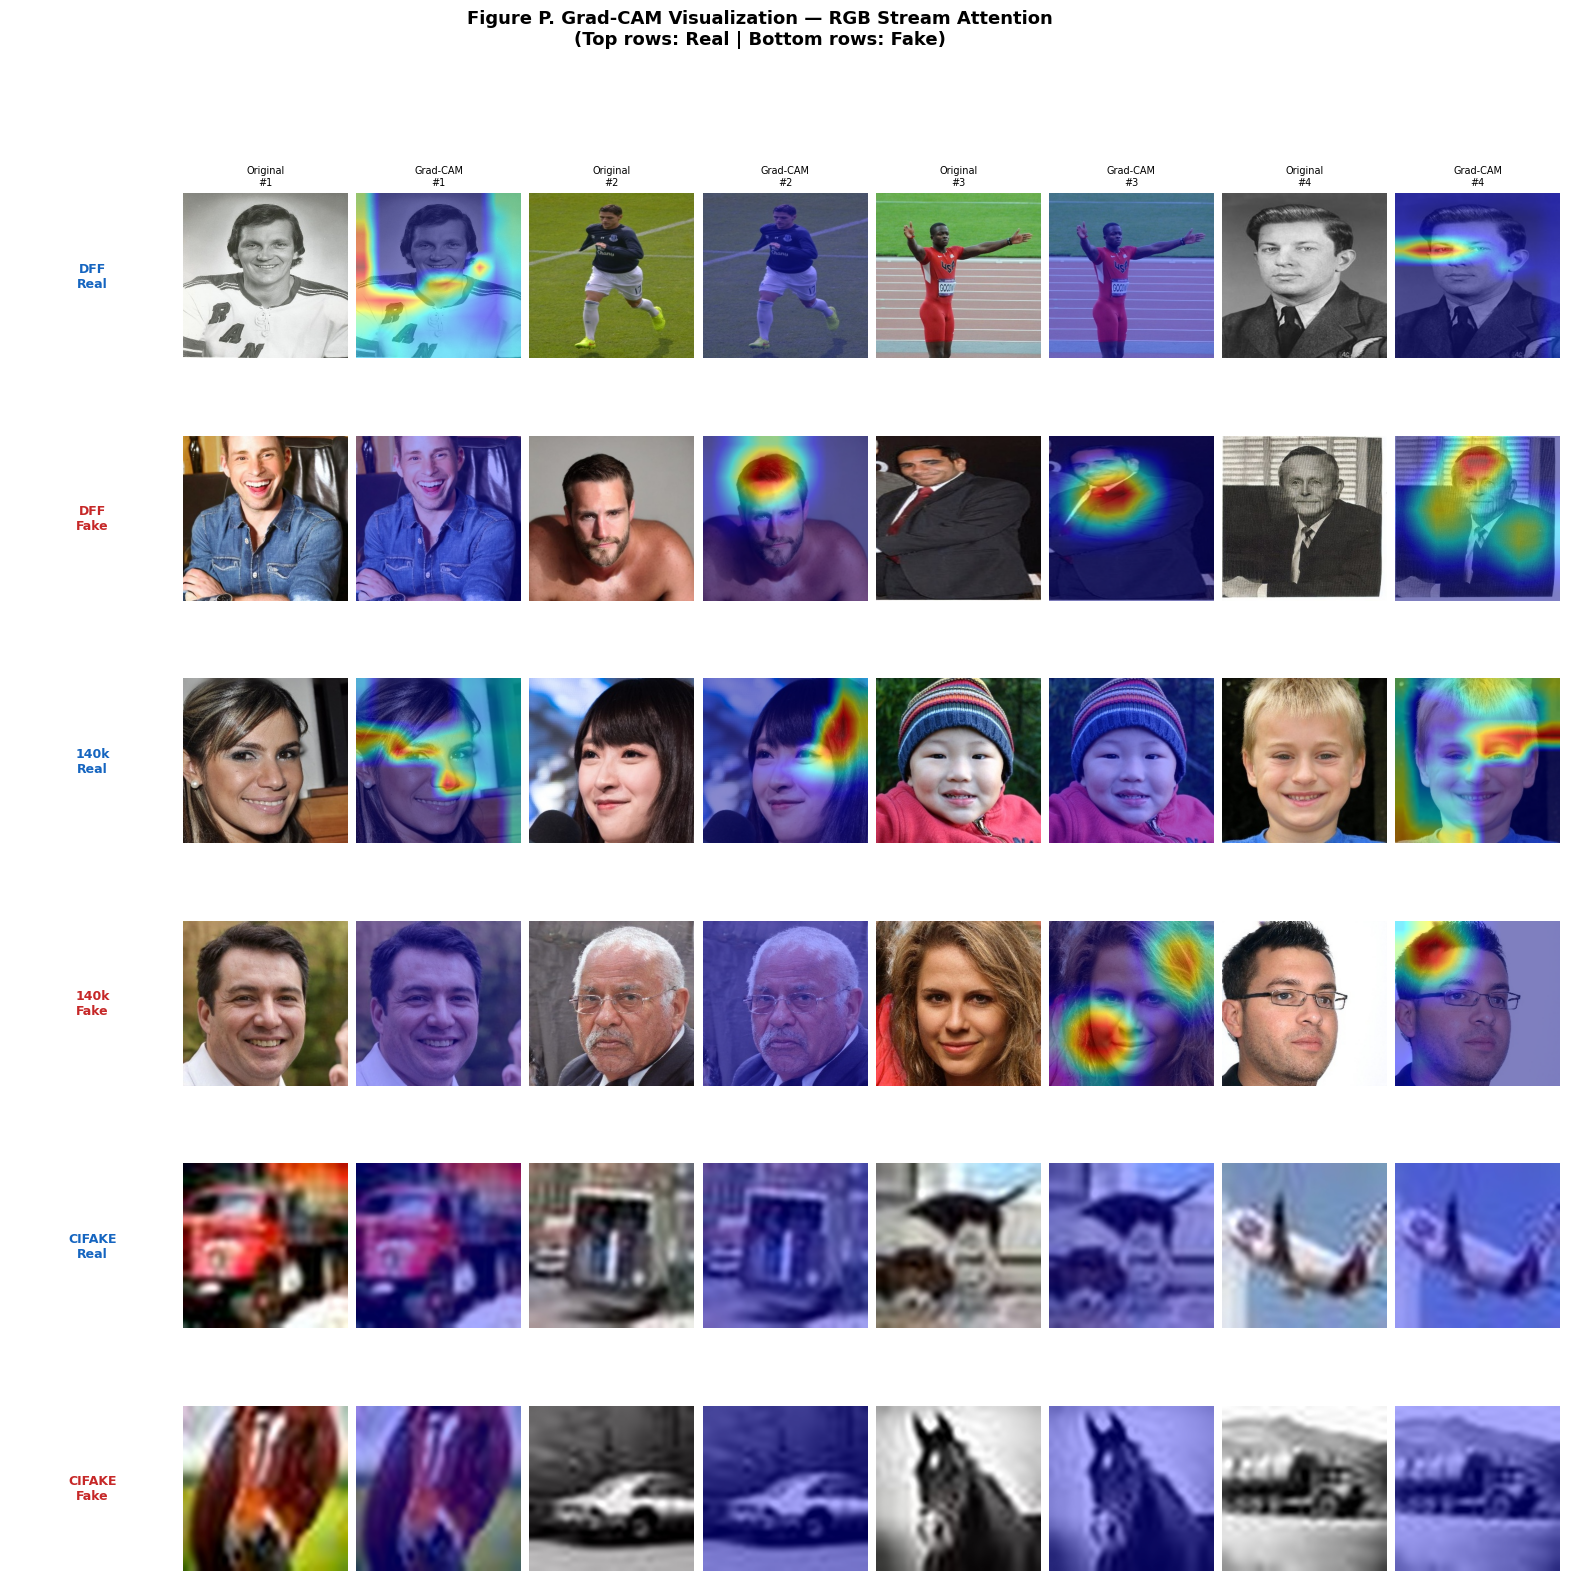

  Saved → eda_outputs/FigP_gradcam_grid.png

  Computing mean Grad-CAM activation intensity ...


  Grad-CAM intensity: 100%|████████████████████████████████████████████████████████████| 48/48 [00:03<00:00, 15.82it/s]


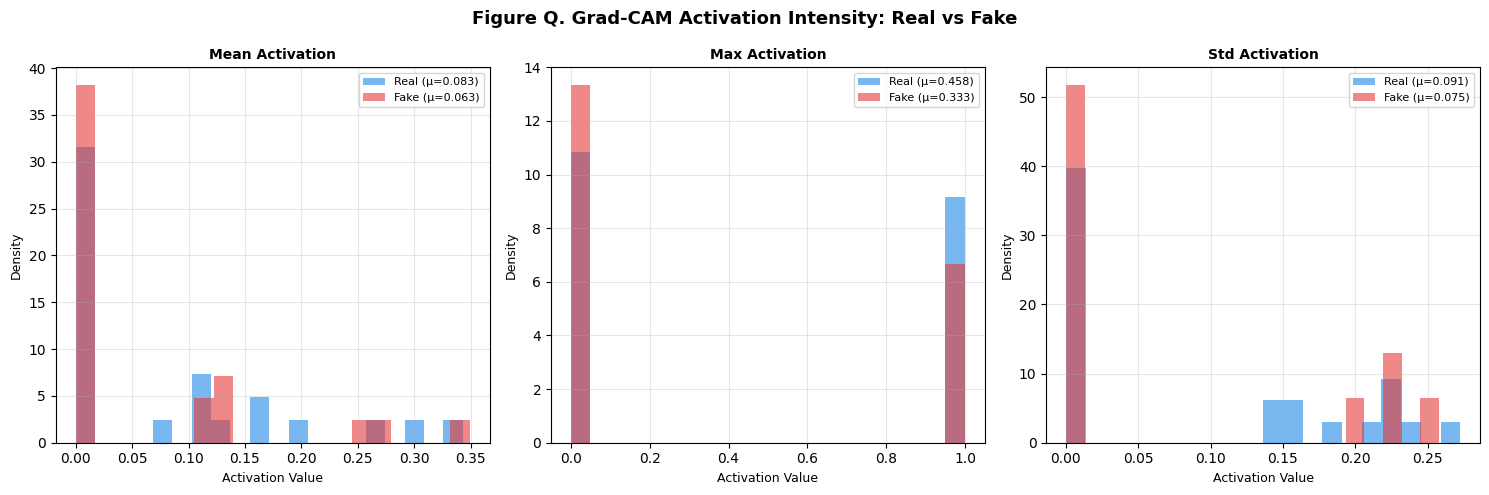

  Saved → eda_outputs/FigQ_gradcam_intensity.png
  t-test (Real vs Fake mean activation): t=0.6347, p=0.528788 (not significant)

EXP-09. FFT Spectrum Analysis
  Computing mean FFT spectrum for Real images ...


  Computing mean FFT spectrum for Fake images ...


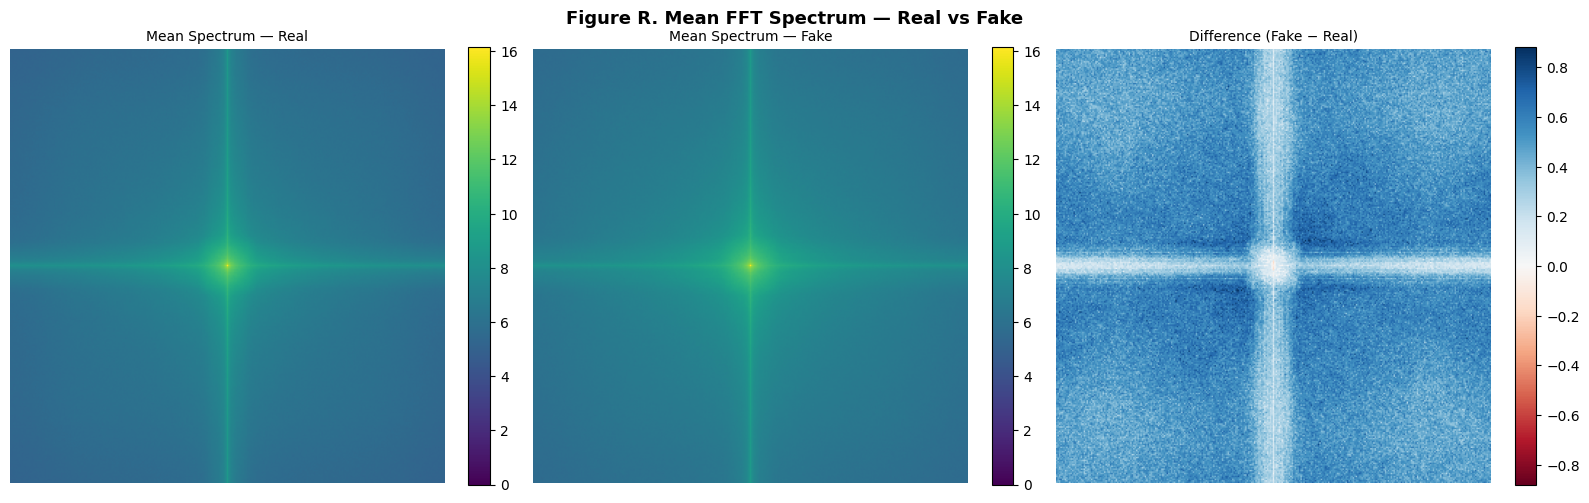

  Saved → eda_outputs/FigR_fft_spectrum.png
  Computing radial power spectral density ...


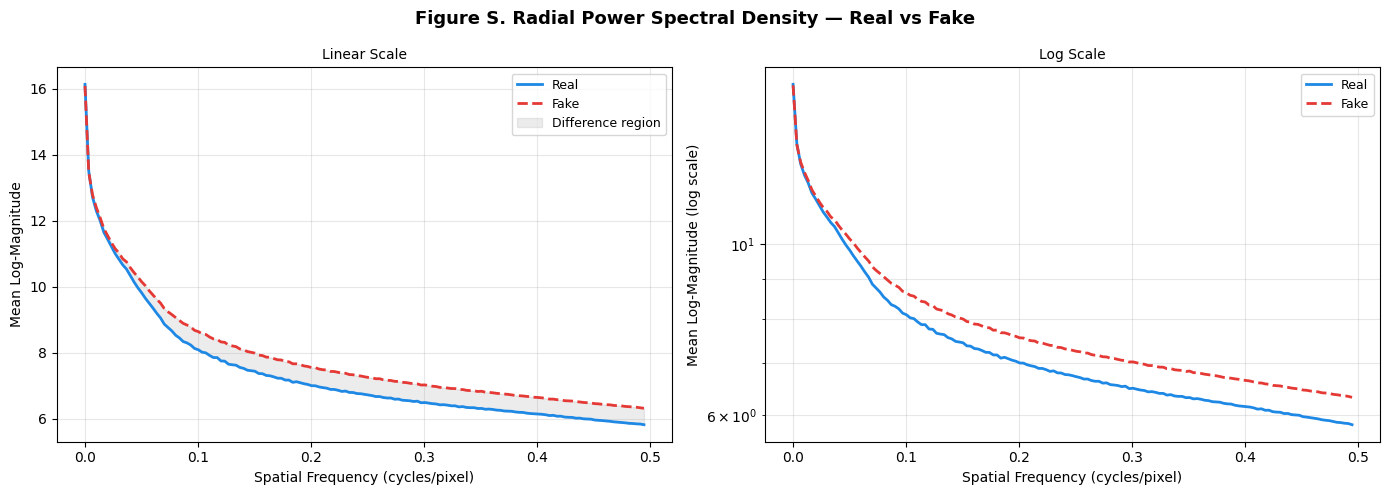

  Saved → eda_outputs/FigS_radial_psd.png
  Computing frequency band energy distribution ...
        Band     Real     Fake  Diff (Fake-Real)
  Low (<20%) 9.280501 9.692094            0.4116
Mid (20–60%) 6.994952 7.540285            0.5453
 High (>60%) 5.941607 6.441184            0.4996
  Saved → explainability_outputs/fft_band_energy.csv


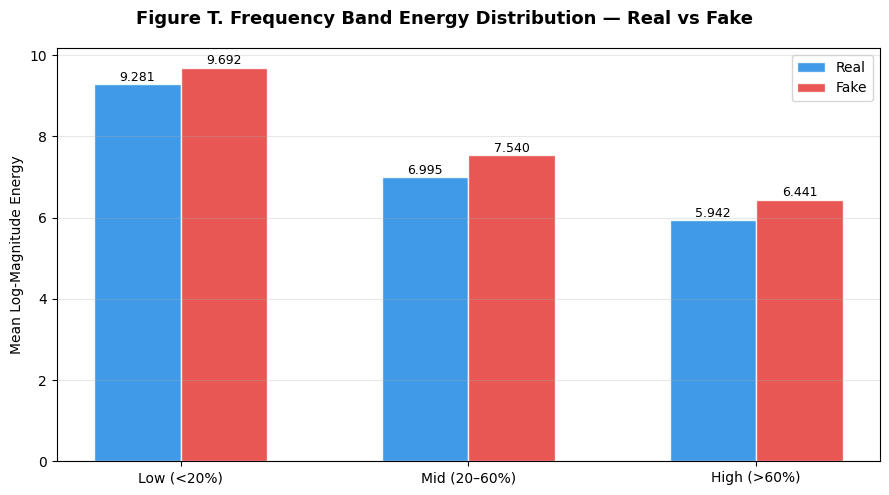

  Saved → eda_outputs/FigT_freq_band_energy.png

08. Explainability Summary Report

  [EXP-08] Grad-CAM Activation (Real vs Fake):
    Real  — mean:0.0827 std:0.1061 max:0.3428
    Fake  — mean:0.0633 std:0.1019 max:0.3493
    t-test p-value: 0.528788 (not significant)

  [EXP-09] FFT Band Energy (Fake − Real):
    Low (<20%)      → Δ=+0.4116 ↑
    Mid (20–60%)    → Δ=+0.5453 ↑
    High (>60%)     → Δ=+0.4996 ↑

  Saved → explainability_outputs/explainability_summary.csv

ALL EXPLAINABILITY EXPERIMENTS COMPLETE.

Outputs:
  explainability_outputs/gradcam_activation_stats.csv
  explainability_outputs/fft_band_energy.csv
  explainability_outputs/explainability_summary.csv
  eda_outputs/FigP_gradcam_grid.png
  eda_outputs/FigQ_gradcam_intensity.png
  eda_outputs/FigR_fft_spectrum.png
  eda_outputs/FigS_radial_psd.png
  eda_outputs/FigT_freq_band_energy.png

Notebook 07 complete. Proceed to Notebook 08: SOTA Comparison.


In [1]:
# =============================================================
# Notebook Name: 07_explainability.ipynb
# Project     : Multi-Stream Deepfake Detection (SFRPD-Net Extension)
# Experiments : EXP-08 Grad-CAM | EXP-09 FFT Spectrum Analysis
# =============================================================

# ─────────────────────────────────────────
# 01. Environment Check
# ─────────────────────────────────────────
import sys, torch, platform

print("=" * 50)
print("01. Environment Check")
print("=" * 50)
print(f"Python  : {sys.version}")
print(f"OS      : {platform.system()} {platform.release()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print("=" * 50)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ─────────────────────────────────────────
# 02. Install Required Packages
# ─────────────────────────────────────────
import subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

pip_install("grad-cam")
pip_install("timm")
pip_install("albumentations")
pip_install("opencv-python")
pip_install("matplotlib")
pip_install("seaborn")
pip_install("scipy")
print("02. Package installation complete.")


# ─────────────────────────────────────────
# 03. Import Libraries
# ─────────────────────────────────────────
import warnings, random
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy import stats
from scipy.signal import welch

import torch
import torch.nn as nn
import torchvision.models as models
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("03. All libraries imported successfully.")


# ─────────────────────────────────────────
# 04. Paths & Configuration
# ─────────────────────────────────────────
IMG_SIZE    = 299
BATCH_SIZE  = 32
RANDOM_SEED = 42
N_SAMPLES   = 8    # samples per class for visualization

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

EXPORT_DIR  = Path("./export")
SPLIT_DIR   = Path("./processed/splits")
TRACK1_DIR  = Path("./processed/track1_face")
TRACK2_DIR  = Path("./processed/track2_fullscene")
CKPT_DIR    = Path("./checkpoints")
EDA_DIR     = Path("./eda_outputs")
XAI_DIR     = Path("./explainability_outputs")

for d in [EDA_DIR, XAI_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

BEST_MODEL_NAME = "xcep_rgb_fft_phy"
BEST_BACKBONE   = "xception"
BEST_STREAMS    = ["rgb", "fft", "phy"]

print("04. Configuration set.")


# ─────────────────────────────────────────
# 05. Model Definition & Load
# ─────────────────────────────────────────
def build_backbone(backbone_name: str, out_dim: int = 256) -> nn.Module:
    if backbone_name == "vgg16":
        base = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_f = base.classifier[0].in_features
        base.classifier = nn.Sequential(
            nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, out_dim), nn.ReLU(),
        )
    elif backbone_name == "xception":
        base = timm.create_model("xception", pretrained=False, num_classes=0)
        in_f = base.num_features
        base = nn.Sequential(
            base,
            nn.Linear(in_f, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, out_dim), nn.ReLU(),
        )
    return base


class SFRPDNet(nn.Module):
    def __init__(self, backbone, stream_dim=256,
                 active_streams=["rgb","fft","phy"]):
        super().__init__()
        self.active_streams = active_streams
        if "rgb" in active_streams:
            self.rgb_stream = build_backbone(backbone, stream_dim)
        if "fft" in active_streams:
            self.fft_stream = build_backbone(backbone, stream_dim)
        if "phy" in active_streams:
            self.phy_stream = build_backbone(backbone, stream_dim)
        self.gates = nn.ParameterDict({
            s: nn.Parameter(torch.ones(1)) for s in active_streams
        })
        fused_dim = stream_dim * len(active_streams)
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, batch):
        feats = []
        if "rgb" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["rgb"]) *
                         self.rgb_stream(batch["rgb"]))
        if "fft" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["fft"]) *
                         self.fft_stream(batch["fft"]))
        if "phy" in self.active_streams:
            feats.append(torch.sigmoid(self.gates["phy"]) *
                         self.phy_stream(batch["phy"]))
        return self.classifier(torch.cat(feats, dim=1))


best_model = SFRPDNet(BEST_BACKBONE,
                      active_streams=BEST_STREAMS).to(DEVICE)
best_model.load_state_dict(
    torch.load(CKPT_DIR / f"{BEST_MODEL_NAME}_best.pt",
               map_location=DEVICE))
best_model.eval()
print(f"05. Best model loaded: {BEST_MODEL_NAME}")


# ─────────────────────────────────────────
# 06. Sample Images for Visualization
# ─────────────────────────────────────────
EVAL_TF = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

df_test = pd.read_csv(SPLIT_DIR / "test.csv")

# Sample N_SAMPLES real and fake from each source
sample_rows = []
for label, cls in [(0, "real"), (1, "fake")]:
    for src in ["DFF", "140k", "CIFAKE"]:
        subset = df_test[
            (df_test["label"] == label) &
            (df_test["source"] == src)
        ]
        sampled = subset.sample(
            min(N_SAMPLES, len(subset)),
            random_state=RANDOM_SEED
        )
        sample_rows.append(sampled)

df_samples = pd.concat(sample_rows, ignore_index=True)
print(f"06. Sampled {len(df_samples)} images for visualization "
      f"(Real: {(df_samples['label']==0).sum()} | "
      f"Fake: {(df_samples['label']==1).sum()})")


# ─────────────────────────────────────────
# 07. Grad-CAM Setup
# ─────────────────────────────────────────
# Target layer: last conv block of Xception RGB stream
# rgb_stream[0] is the timm Xception base model
target_layer = [best_model.rgb_stream[0].conv4]  # last conv block

class RGBOnlyWrapper(nn.Module):
    """Wrapper to feed only RGB input for Grad-CAM compatibility."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        batch = {
            "rgb": x,
            "fft": torch.zeros_like(x),
            "phy": torch.zeros_like(x),
        }
        return self.model(batch)

wrapper = RGBOnlyWrapper(best_model).to(DEVICE)
wrapper.eval()

cam = GradCAM(
    model=wrapper,
    target_layers=target_layer,
)
print("07. Grad-CAM initialized on RGB stream last conv layer.")


# ═══════════════════════════════════════════════════════════════
# EXP-08. Grad-CAM Visualization
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXP-08. Grad-CAM Visualization")
print("=" * 60)

def load_rgb(path: str) -> np.ndarray:
    """Load image as RGB numpy array, resized to IMG_SIZE."""
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.array(img)

def get_gradcam(img_np: np.ndarray, target_class: int) -> np.ndarray:
    """Compute Grad-CAM heatmap for given image and target class."""
    img_norm = EVAL_TF(image=img_np)["image"].unsqueeze(0).to(DEVICE)
    targets  = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=img_norm, targets=targets)
    return grayscale_cam[0]


# ── Figure P: Grad-CAM Grid (Real vs Fake per Source) ──
sources  = ["DFF", "140k", "CIFAKE"]
n_show   = 4   # images per (source × class)

fig = plt.figure(figsize=(20, 18))
fig.suptitle(
    "Figure P. Grad-CAM Visualization — RGB Stream Attention\n"
    "(Top rows: Real | Bottom rows: Fake)",
    fontsize=13, fontweight="bold"
)

gs = gridspec.GridSpec(len(sources) * 2, n_show * 2 + 1,
                       hspace=0.4, wspace=0.05)

for s_idx, src in enumerate(sources):
    for l_idx, (label, cls) in enumerate([(0, "Real"), (1, "Fake")]):
        row = s_idx * 2 + l_idx
        subset = df_samples[
            (df_samples["source"] == src) &
            (df_samples["label"]  == label)
        ].head(n_show)

        # Row label
        ax_label = fig.add_subplot(gs[row, 0])
        ax_label.text(0.5, 0.5,
                      f"{src}\n{cls}",
                      ha="center", va="center",
                      fontsize=9, fontweight="bold",
                      color="#1565C0" if label == 0 else "#C62828")
        ax_label.axis("off")

        for i, (_, row_data) in enumerate(subset.iterrows()):
            img_np  = load_rgb(row_data["track1_path"])
            img_f   = img_np.astype(np.float32) / 255.0
            cam_map = get_gradcam(img_np, target_class=label)
            overlay = show_cam_on_image(img_f, cam_map, use_rgb=True)

            # Original
            ax_orig = fig.add_subplot(gs[row, i * 2 + 1])
            ax_orig.imshow(img_np)
            ax_orig.axis("off")
            if row == 0:
                ax_orig.set_title(f"Original\n#{i+1}",
                                  fontsize=7)

            # Grad-CAM overlay
            ax_cam = fig.add_subplot(gs[row, i * 2 + 2])
            ax_cam.imshow(overlay)
            ax_cam.axis("off")
            if row == 0:
                ax_cam.set_title(f"Grad-CAM\n#{i+1}",
                                 fontsize=7)

plt.savefig(EDA_DIR / "FigP_gradcam_grid.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigP_gradcam_grid.png")


# ── Figure Q: Grad-CAM Activation Intensity (Real vs Fake) ──
print("\n  Computing mean Grad-CAM activation intensity ...")

activation_rows = []
for _, row_data in tqdm(df_samples.iterrows(),
                        total=len(df_samples),
                        desc="  Grad-CAM intensity"):
    try:
        img_np  = load_rgb(row_data["track1_path"])
        cam_map = get_gradcam(img_np, target_class=int(row_data["label"]))
        activation_rows.append({
            "label"      : row_data["label"],
            "source"     : row_data["source"],
            "mean_act"   : float(cam_map.mean()),
            "max_act"    : float(cam_map.max()),
            "std_act"    : float(cam_map.std()),
        })
    except Exception:
        pass

df_act = pd.DataFrame(activation_rows)
df_act.to_csv(XAI_DIR / "gradcam_activation_stats.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure Q. Grad-CAM Activation Intensity: Real vs Fake",
             fontsize=13, fontweight="bold")

for ax, metric, title in [
    (axes[0], "mean_act", "Mean Activation"),
    (axes[1], "max_act",  "Max Activation"),
    (axes[2], "std_act",  "Std Activation"),
]:
    for label, cls, col in [(0,"Real","#1e88e5"),(1,"Fake","#e53935")]:
        vals = df_act[df_act["label"]==label][metric].values
        ax.hist(vals, bins=20, alpha=0.6, color=col,
                label=f"{cls} (μ={vals.mean():.3f})",
                density=True)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Activation Value", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigQ_gradcam_intensity.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigQ_gradcam_intensity.png")

# t-test: Real vs Fake activation
t_stat, p_val = stats.ttest_ind(
    df_act[df_act["label"]==0]["mean_act"].values,
    df_act[df_act["label"]==1]["mean_act"].values,
)
print(f"  t-test (Real vs Fake mean activation): "
      f"t={t_stat:.4f}, p={p_val:.6f} "
      f"({'significant' if p_val < 0.05 else 'not significant'})")


# ═══════════════════════════════════════════════════════════════
# EXP-09. FFT Spectrum Analysis
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("EXP-09. FFT Spectrum Analysis")
print("=" * 60)

N_FFT = 200   # images per class for spectral analysis

df_fft_real = df_test[df_test["label"]==0].sample(
    N_FFT, random_state=RANDOM_SEED)
df_fft_fake = df_test[df_test["label"]==1].sample(
    N_FFT, random_state=RANDOM_SEED)


def compute_mean_spectrum(df_subset: pd.DataFrame) -> np.ndarray:
    """Compute mean log-magnitude FFT spectrum across images."""
    spectra = []
    for _, row in tqdm(df_subset.iterrows(),
                       total=len(df_subset), leave=False):
        try:
            img = np.array(
                Image.open(row["track1_path"]).convert("L")
                     .resize((IMG_SIZE, IMG_SIZE))
            ).astype(np.float32)
            f   = np.fft.fft2(img)
            fs  = np.fft.fftshift(f)
            mag = np.log1p(np.abs(fs))
            spectra.append(mag)
        except Exception:
            pass
    return np.mean(spectra, axis=0) if spectra else np.zeros((IMG_SIZE, IMG_SIZE))


print("  Computing mean FFT spectrum for Real images ...")
mean_spec_real = compute_mean_spectrum(df_fft_real)
print("  Computing mean FFT spectrum for Fake images ...")
mean_spec_fake = compute_mean_spectrum(df_fft_fake)
diff_spec      = mean_spec_fake - mean_spec_real


# ── Figure R: Mean FFT Spectrum Comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure R. Mean FFT Spectrum — Real vs Fake",
             fontsize=13, fontweight="bold")

vmax = max(mean_spec_real.max(), mean_spec_fake.max())

im0 = axes[0].imshow(mean_spec_real, cmap="viridis",
                     vmin=0, vmax=vmax)
axes[0].set_title("Mean Spectrum — Real", fontsize=10)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mean_spec_fake, cmap="viridis",
                     vmin=0, vmax=vmax)
axes[1].set_title("Mean Spectrum — Fake", fontsize=10)
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

abs_max = np.abs(diff_spec).max()
im2 = axes[2].imshow(diff_spec, cmap="RdBu",
                     vmin=-abs_max, vmax=abs_max)
axes[2].set_title("Difference (Fake − Real)", fontsize=10)
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigR_fft_spectrum.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigR_fft_spectrum.png")


# ── Figure S: Radial Power Spectral Density ──
print("  Computing radial power spectral density ...")

def radial_psd(spectrum: np.ndarray) -> tuple:
    """Compute radially averaged power spectral density."""
    h, w   = spectrum.shape
    cy, cx = h // 2, w // 2
    Y, X   = np.ogrid[:h, :w]
    R      = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
    r_max  = min(cx, cy)
    psd    = np.array([spectrum[R == r].mean()
                       for r in range(r_max)])
    freqs  = np.arange(r_max) / max(h, w)
    return freqs, psd


freqs_r, psd_real = radial_psd(mean_spec_real)
freqs_f, psd_fake = radial_psd(mean_spec_fake)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure S. Radial Power Spectral Density — Real vs Fake",
             fontsize=13, fontweight="bold")

# Linear scale
axes[0].plot(freqs_r, psd_real, color="#1e88e5", lw=2, label="Real")
axes[0].plot(freqs_f, psd_fake, color="#e53935", lw=2,
             linestyle="--", label="Fake")
axes[0].fill_between(freqs_r, psd_real, psd_fake,
                     alpha=0.15, color="gray",
                     label="Difference region")
axes[0].set_xlabel("Spatial Frequency (cycles/pixel)", fontsize=10)
axes[0].set_ylabel("Mean Log-Magnitude", fontsize=10)
axes[0].set_title("Linear Scale", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].semilogy(freqs_r, psd_real, color="#1e88e5", lw=2, label="Real")
axes[1].semilogy(freqs_f, psd_fake, color="#e53935", lw=2,
                 linestyle="--", label="Fake")
axes[1].set_xlabel("Spatial Frequency (cycles/pixel)", fontsize=10)
axes[1].set_ylabel("Mean Log-Magnitude (log scale)", fontsize=10)
axes[1].set_title("Log Scale", fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(EDA_DIR / "FigS_radial_psd.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigS_radial_psd.png")


# ── Frequency Band Energy Analysis ──
print("  Computing frequency band energy distribution ...")

def band_energy(spectrum: np.ndarray) -> dict:
    """Split spectrum into low/mid/high frequency bands."""
    h, w   = spectrum.shape
    cy, cx = h // 2, w // 2
    Y, X   = np.ogrid[:h, :w]
    R      = np.sqrt((X - cx)**2 + (Y - cy)**2)
    r_max  = min(cx, cy)
    low    = spectrum[R <= r_max * 0.2].mean()
    mid    = spectrum[(R > r_max*0.2) & (R <= r_max*0.6)].mean()
    high   = spectrum[R > r_max * 0.6].mean()
    return {"Low (<20%)": low, "Mid (20–60%)": mid, "High (>60%)": high}

bands_real = band_energy(mean_spec_real)
bands_fake = band_energy(mean_spec_fake)

df_bands = pd.DataFrame({
    "Band"  : list(bands_real.keys()),
    "Real"  : list(bands_real.values()),
    "Fake"  : list(bands_fake.values()),
})
df_bands["Diff (Fake-Real)"] = (df_bands["Fake"] - df_bands["Real"]).round(4)
df_bands.to_csv(XAI_DIR / "fft_band_energy.csv", index=False)
print(df_bands.to_string(index=False))
print("  Saved → explainability_outputs/fft_band_energy.csv")


# ── Figure T: Frequency Band Energy Bar Chart ──
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Figure T. Frequency Band Energy Distribution — Real vs Fake",
             fontsize=13, fontweight="bold")

x      = np.arange(len(df_bands))
width  = 0.3
bars_r = ax.bar(x - width/2, df_bands["Real"].values,
                width, label="Real", color="#1e88e5", alpha=0.85,
                edgecolor="white")
bars_f = ax.bar(x + width/2, df_bands["Fake"].values,
                width, label="Fake", color="#e53935", alpha=0.85,
                edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(df_bands["Band"].values, fontsize=10)
ax.set_ylabel("Mean Log-Magnitude Energy", fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

for bars in [bars_r, bars_f]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "FigT_freq_band_energy.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("  Saved → eda_outputs/FigT_freq_band_energy.png")


# ─────────────────────────────────────────
# 08. Explainability Summary Report
# ─────────────────────────────────────────
print("\n" + "=" * 60)
print("08. Explainability Summary Report")
print("=" * 60)

print("\n  [EXP-08] Grad-CAM Activation (Real vs Fake):")
for label, cls in [(0,"Real"),(1,"Fake")]:
    vals = df_act[df_act["label"]==label]["mean_act"].values
    print(f"    {cls:5s} — mean:{vals.mean():.4f} "
          f"std:{vals.std():.4f} max:{vals.max():.4f}")
print(f"    t-test p-value: {p_val:.6f} "
      f"({'significant' if p_val < 0.05 else 'not significant'})")

print("\n  [EXP-09] FFT Band Energy (Fake − Real):")
for _, r in df_bands.iterrows():
    sign = "↑" if r["Diff (Fake-Real)"] > 0 else "↓"
    print(f"    {r['Band']:15s} → Δ={r['Diff (Fake-Real)']:+.4f} {sign}")

# Save summary
summary = {
    "GradCAM_real_mean"  : df_act[df_act["label"]==0]["mean_act"].mean(),
    "GradCAM_fake_mean"  : df_act[df_act["label"]==1]["mean_act"].mean(),
    "GradCAM_ttest_p"    : p_val,
    "FFT_low_diff"       : df_bands.loc[0,"Diff (Fake-Real)"],
    "FFT_mid_diff"       : df_bands.loc[1,"Diff (Fake-Real)"],
    "FFT_high_diff"      : df_bands.loc[2,"Diff (Fake-Real)"],
}
pd.DataFrame([summary]).to_csv(
    XAI_DIR / "explainability_summary.csv", index=False)
print("\n  Saved → explainability_outputs/explainability_summary.csv")

print("\n" + "=" * 60)
print("ALL EXPLAINABILITY EXPERIMENTS COMPLETE.")
print("=" * 60)
print("\nOutputs:")
print("  explainability_outputs/gradcam_activation_stats.csv")
print("  explainability_outputs/fft_band_energy.csv")
print("  explainability_outputs/explainability_summary.csv")
print("  eda_outputs/FigP_gradcam_grid.png")
print("  eda_outputs/FigQ_gradcam_intensity.png")
print("  eda_outputs/FigR_fft_spectrum.png")
print("  eda_outputs/FigS_radial_psd.png")
print("  eda_outputs/FigT_freq_band_energy.png")
print("\nNotebook 07 complete. Proceed to Notebook 08: SOTA Comparison.")